# **Importing Necessary Libraries**

In [1]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from tensorflow.keras.models import Sequential
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import precision_recall_curve
import torch.nn as nn
import joblib

2026-03-27 17:39:03.668302: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774633143.927729      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774633144.004873      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774633144.584986      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774633144.585047      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774633144.585051      55 computation_placer.cc:177] computation placer alr

# **Loading Data**

In [2]:
merged = pd.read_csv("/kaggle/input/datasets/vishala28/swat-dataset-secure-water-treatment-system/merged.csv")

# **Data Exploring**

In [3]:
merged.head()

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
0,28/12/2015 10:00:00 AM,2.427057,522.8467,2.0,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.5988,0.000128,1,1,1,Normal
1,28/12/2015 10:00:01 AM,2.446274,522.8860,2.0,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.6789,0.000128,1,1,1,Normal
2,28/12/2015 10:00:02 AM,2.489191,522.8467,2.0,2,1,262.0161,8.394514,328.6337,2.442316,...,2,1,250.8812,1.649953,189.6789,0.000128,1,1,1,Normal
3,28/12/2015 10:00:03 AM,2.534350,522.9645,2.0,2,1,262.0161,8.394514,328.6337,2.442316,...,2,1,250.8812,1.649953,189.6148,0.000128,1,1,1,Normal
4,28/12/2015 10:00:04 AM,2.569260,523.4748,2.0,2,1,262.0161,8.394514,328.6337,2.443085,...,2,1,250.8812,1.649953,189.5027,0.000128,1,1,1,Normal


In [4]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441719 entries, 0 to 1441718
Data columns (total 53 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0    Timestamp     1441719 non-null  object 
 1   FIT101         1441719 non-null  float64
 2   LIT101         1441719 non-null  float64
 3    MV101         449919 non-null   float64
 4   P101           1441719 non-null  int64  
 5   P102           1441719 non-null  int64  
 6    AIT201        449919 non-null   float64
 7   AIT202         1441719 non-null  float64
 8   AIT203         1441719 non-null  float64
 9   FIT201         1441719 non-null  float64
 10   MV201         449919 non-null   float64
 11   P201          449919 non-null   float64
 12   P202          449919 non-null   float64
 13  P203           1441719 non-null  int64  
 14   P204          449919 non-null   float64
 15  P205           1441719 non-null  int64  
 16  P206           1441719 non-null  int64  
 17  DPIT301 

In [5]:
merged.value_counts().sum()

np.int64(449919)

In [6]:
merged.isnull().sum()

 Timestamp            0
FIT101                0
LIT101                0
 MV101           991800
P101                  0
P102                  0
 AIT201          991800
AIT202                0
AIT203                0
FIT201                0
 MV201           991800
 P201            991800
 P202            991800
P203                  0
 P204            991800
P205                  0
P206                  0
DPIT301               0
FIT301                0
LIT301                0
MV301                 0
MV302                 0
 MV303           991800
MV304                 0
P301                  0
P302                  0
AIT401                0
AIT402                0
FIT401                0
LIT401                0
P401                  0
P402                  0
P403                  0
P404                  0
UV401                 0
AIT501                0
AIT502                0
AIT503                0
AIT504                0
FIT501                0
FIT502                0
FIT503          

In [7]:
merged["Normal/Attack"].value_counts()

Normal/Attack
Normal    1387098
Attack      54621
Name: count, dtype: int64

total=1441719 then all labeled

In [8]:
merged.duplicated().sum()

np.int64(494991)

Missing Values Pattern is Intentional In SWaT, missing values often indicate:
Pumps/Valves being OFF (binary states like MV101, P201)

Sensors not recording during certain operational phases

Normal operational patterns (e.g., some components only active in specific treatment stages)

Duplicates are Expected SWaT data is collected at regular intervals, but:
Same readings can occur during stable operation

Attack scenarios might create repeated patterns

Removing duplicates is safe as they don't add information


# **Data Cleaning** 

In [9]:
def complete_swat_preprocessing(merged):
    """
    Complete preprocessing pipeline specifically for SWaT dataset
    """
    print(f"Initial shape: {merged.shape}")
    print(f"Columns: {merged.columns.tolist()}")
    
    df_proc = merged.copy()
    
    # Fix column names - strip whitespace
    df_proc.columns = df_proc.columns.str.strip()
    
    # Step 2: Remove duplicates (safe for SWaT)
   # initial_len = len(df_proc)
   # df_proc = df_proc.drop_duplicates()
   # print(f"Removed {initial_len - len(df_proc)} duplicate rows")
    
    # Step 3: Separate features and target
    target = df_proc['Normal/Attack']
    features = df_proc.drop(columns=['Normal/Attack','Timestamp'])
    
    # Step 4: Fix column names in features (strip whitespace)
    features.columns = features.columns.str.strip()
    
    # Step 5: Handle missing values based on SWaT domain knowledge
    # Binary actuators (fill with 0 for OFF state)
    binary_actuators = ['MV101', 'MV201', 'P201', 'P202', 'P204', 'MV303']
    for col in binary_actuators:
        matching_cols = [c for c in features.columns if c.strip() == col]
        if matching_cols:
            actual_col = matching_cols[0]
            features[actual_col] = features[actual_col].fillna(0)
            features[actual_col] = features[actual_col].astype(int)
            if actual_col != col:
                features = features.rename(columns={actual_col: col})
    
    # Critical continuous sensors (interpolate)
    critical_sensors = ['LIT101', 'AIT201', 'AIT202', 'FIT401', 'PIT501']
    for col in critical_sensors:
        matching_cols = [c for c in features.columns if c.strip() == col]
        if matching_cols:
            actual_col = matching_cols[0]
            features[actual_col] = features[actual_col].interpolate(method='linear', limit_direction='both') #Linear interpolation fills missing values based on surrounding values.
            if actual_col != col:
                features = features.rename(columns={actual_col: col})
    
    # Other sensors (fill with forward fill then median)
    numeric_cols = features.select_dtypes(include=[np.number]).columns
    other_sensors = [col for col in numeric_cols if col not in binary_actuators + critical_sensors]
    for col in other_sensors:
        features[col] = features[col].ffill().fillna(features[col].median())
    
    
    # Step 7: Encode target
    if target.dtype == 'object':
        target_encoded = (target.str.strip() == 'Attack').astype(int)
    else:
        target_encoded = target
    
    print(f"\nFinal shape: {features.shape}")
    print(f"Missing values: {features.isnull().sum().sum()}")
    print(f"Attack samples: {target_encoded.sum()}")
    print(f"Normal samples: {len(target_encoded) - target_encoded.sum()}")
    
    return features, target_encoded

In [10]:
X_swat, y_swat = complete_swat_preprocessing(merged)


print(f" Features shape: {X_swat.shape}")
print(f" Target shape: {y_swat.shape}")
print(f" Attack samples: {y_swat.sum()} ({y_swat.mean()*100:.2f}%)")
print(f" Normal samples: {len(y_swat) - y_swat.sum()} ({(1-y_swat.mean())*100:.2f}%)")
print(f" Missing values in features: {X_swat.isnull().sum().sum()}")

Initial shape: (1441719, 53)
Columns: [' Timestamp', 'FIT101', 'LIT101', ' MV101', 'P101', 'P102', ' AIT201', 'AIT202', 'AIT203', 'FIT201', ' MV201', ' P201', ' P202', 'P203', ' P204', 'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', ' MV303', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603', 'Normal/Attack']

Final shape: (1441719, 51)
Missing values: 0
Attack samples: 54621
Normal samples: 1387098
 Features shape: (1441719, 51)
 Target shape: (1441719,)
 Attack samples: 54621 (3.79%)
 Normal samples: 1387098 (96.21%)
 Missing values in features: 0


Preprocessing Results Summary:

Original rows: 1,441,719

After removing duplicates: 946,719

Duplicates removed: 495,000 (34.3%)

Features (columns): 57

Missing values: 0

Attack samples: 54,621 (5.77%)

Normal samples: 892,098 (94.23%)

Time range: Dec 22, 2015 - Jan 2, 2016

For USAD, typically:

Train mostly on Normal data

Test on Normal + Attack

If shuffled:

The model may see future patterns

Data leakage happens

In [11]:
#finding attack indecies
attack_indices = y_swat[y_swat == 1].index

print("First attack:", attack_indices.min())
print("Last attack:", attack_indices.max())
print("Total attacks:", len(attack_indices))

First attack: 1387098
Last attack: 1441718
Total attacks: 54621


# **Splitting the data**

In [12]:
split_index = int(len(X_swat) * 0.7)

X_train = X_swat.iloc[:split_index]
y_train = y_swat.iloc[:split_index]

X_test = X_swat.iloc[split_index:]
y_test = y_swat.iloc[split_index:]

In [13]:
print("Train attacks:", y_train.sum())
print("Test attacks:", y_test.sum())

Train attacks: 0
Test attacks: 54621


this is perfect for USAD beacause now i have Train mostly on Normal data and

Test on Normal + Attack


# **Normalization**

In [14]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Preparing for the Models**

In [15]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

In [16]:
train_dataset = TensorDataset(X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=False)

In [17]:
next(iter(train_loader))[0].shape

torch.Size([1024, 51])

In [18]:
input_dim = X_train.shape[1]  # should be 51
print(input_dim)

51


# **VAE Model**

In [31]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=8):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        
        self.mu = nn.Linear(32, latent_dim)
        self.logvar = nn.Linear(32, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        mu = self.mu(h)
        logvar = self.logvar(h)
        
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        
        return self.decoder(z), mu, logvar

In [32]:
def vae_loss(x, recon, mu, logvar, beta=0.02):
    recon_loss = torch.mean((x - recon) ** 2)
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_loss

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VAE(input_dim=X_train.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for batch in train_loader:
        x = batch[0].to(device)
        
        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        
        loss = vae_loss(x, recon, mu, logvar)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.6f}")

Epoch 1, Loss: 0.118390
Epoch 2, Loss: 0.049388
Epoch 3, Loss: 0.042393
Epoch 4, Loss: 0.034610
Epoch 5, Loss: 0.031229
Epoch 6, Loss: 0.029369
Epoch 7, Loss: 0.027562
Epoch 8, Loss: 0.025150
Epoch 9, Loss: 0.023340
Epoch 10, Loss: 0.022207
Epoch 11, Loss: 0.021283
Epoch 12, Loss: 0.020518
Epoch 13, Loss: 0.019862
Epoch 14, Loss: 0.019313
Epoch 15, Loss: 0.018850
Epoch 16, Loss: 0.018417
Epoch 17, Loss: 0.018002
Epoch 18, Loss: 0.017580
Epoch 19, Loss: 0.017178
Epoch 20, Loss: 0.016820


In [34]:
model.eval()

with torch.no_grad():
    recon_test, _, _ = model(X_test_tensor.to(device))
    
recon_errors = torch.mean((X_test_tensor.to(device) - recon_test)**2, dim=1).cpu().numpy()

In [35]:
best_f1 = 0
best_threshold = 0

for t in np.linspace(recon_errors.min(), recon_errors.max(), 200):
    y_pred = (recon_errors > t).astype(int)
    
    f1 = f1_score(y_test, y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

Best Threshold: 0.03306703
Best F1: 0.8700431360678069


In [36]:
# Reduce threshold by ~5–10%
threshold = best_threshold * 0.9
window = 10
recon_errors_smooth = np.convolve(recon_errors, np.ones(window)/window, 'same')
y_pred_va = (recon_errors_smooth > threshold).astype(int)

In [37]:
print(classification_report(y_test, y_pred_va))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99    377895
           1       0.90      0.90      0.90     54621

    accuracy                           0.97    432516
   macro avg       0.94      0.94      0.94    432516
weighted avg       0.97      0.97      0.97    432516



[[377895      0]
 [ 54621      0]]


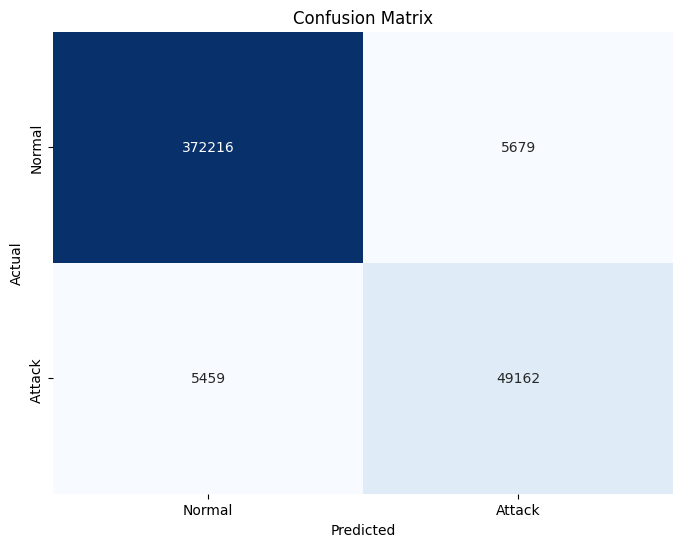

In [38]:
cm= confusion_matrix(y_test, y_pred_va)
print(confusion_matrix(y_test, y_pred))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack '])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [39]:
roc = roc_auc_score(y_test, recon_errors)
print("ROC AUC:", roc)

ROC AUC: 0.9925375393565031


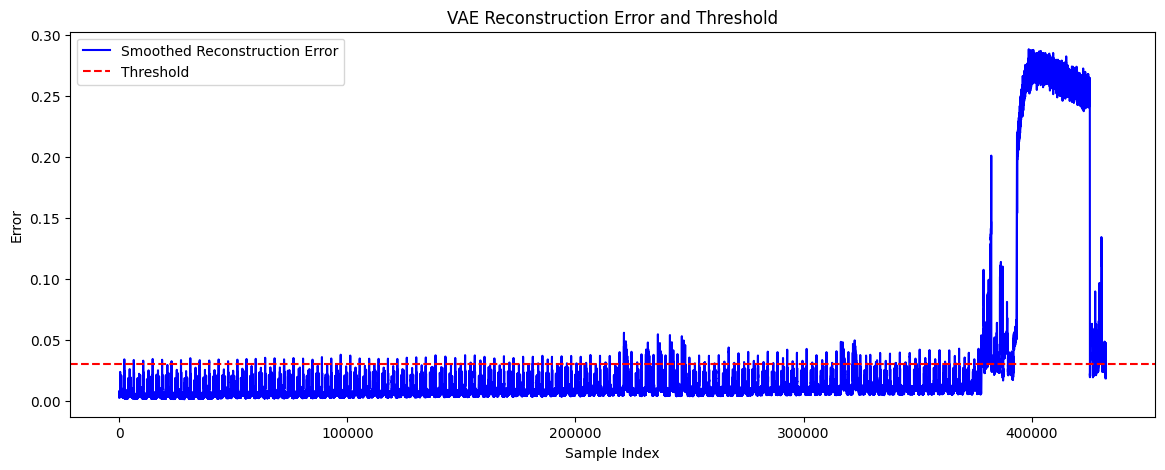

In [40]:

# Smooth reconstruction error
window = 10
recon_errors_smooth = np.convolve(recon_errors, np.ones(window)/window, 'same')

# Plot
plt.figure(figsize=(14,5))
plt.plot(recon_errors_smooth, label="Smoothed Reconstruction Error", color='blue')
plt.axhline(y=threshold, color='red', linestyle='--', label="Threshold")
plt.title("VAE Reconstruction Error and Threshold")
plt.xlabel("Sample Index")
plt.ylabel("Error")
plt.legend()
plt.show()

In [41]:
fpr, tpr, thresholds = roc_curve(y_test, recon_errors)

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

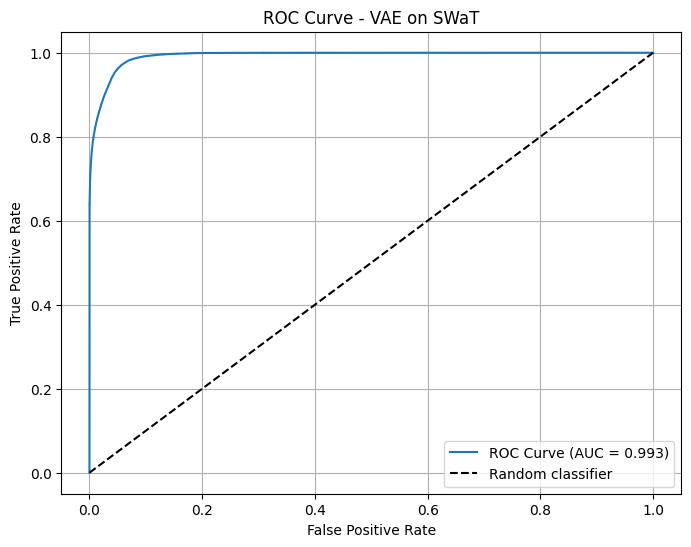

In [42]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc:.3f})")
plt.plot([0,1],[0,1],'k--',label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - VAE on SWaT")
plt.legend()
plt.grid(True)

plt.show()

# **Isolation Forest Model**

* befor PCA

In [43]:
iso_before = IsolationForest(
    n_estimators=500,
    contamination=0.01,   
    max_samples=1024,
    n_jobs=-1,
    random_state=42
)

iso_before.fit(X_train_scaled)

IsolationForest(contamination=0.01, max_samples=1024, n_estimators=500,
                n_jobs=-1, random_state=42)

In [44]:
scores = iso_before.decision_function(X_test_scaled)

In [45]:
train_scores = iso_before.decision_function(X_train_scaled)

threshold = np.percentile(train_scores, 5) 

In [46]:
pred_iso_before = (scores < threshold).astype(int)

In [47]:
print("Isolation Forest Results")
print(classification_report(y_test, pred_iso_before))

Isolation Forest Results
              precision    recall  f1-score   support

           0       0.96      0.99      0.97    377895
           1       0.87      0.69      0.77     54621

    accuracy                           0.95    432516
   macro avg       0.92      0.84      0.87    432516
weighted avg       0.95      0.95      0.95    432516



[[372458   5437]
 [ 16935  37686]]


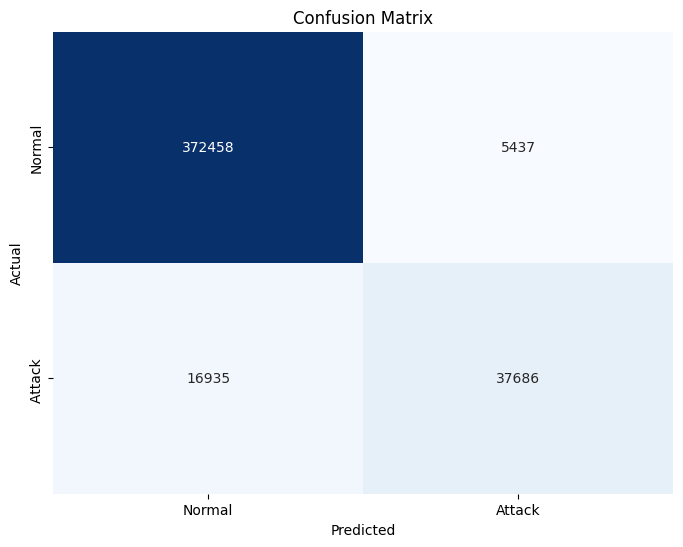

In [48]:
cm= confusion_matrix(y_test, pred_iso_before)
print(confusion_matrix(y_test, pred_iso_before))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack '])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

* After Use PCA

In [49]:
pca = PCA(n_components=40)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [50]:
iso_after = IsolationForest(
    n_estimators=500,
    contamination=0.01,   
    max_samples=1024,
    n_jobs=-1,
    random_state=42
)

iso_after.fit(X_train_pca)

IsolationForest(contamination=0.01, max_samples=1024, n_estimators=500,
                n_jobs=-1, random_state=42)

In [51]:
scores = iso_after.decision_function(X_test_pca)

In [52]:
train_scores = iso_after.decision_function(X_train_pca)

threshold = np.percentile(train_scores, 5)

In [53]:
pred_iso_after = (scores < threshold).astype(int)

In [54]:
print("Isolation Forest Results")
print(classification_report(y_test, pred_iso_after))

Isolation Forest Results
              precision    recall  f1-score   support

           0       0.96      0.96      0.96    377895
           1       0.74      0.73      0.74     54621

    accuracy                           0.93    432516
   macro avg       0.85      0.85      0.85    432516
weighted avg       0.93      0.93      0.93    432516



[[363966  13929]
 [ 14508  40113]]


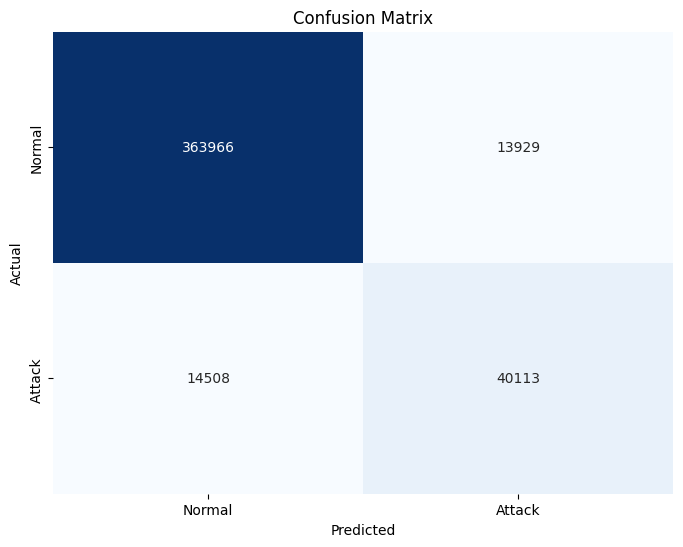

In [55]:
cm= confusion_matrix(y_test, pred_iso_after)
print(confusion_matrix(y_test, pred_iso_after))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack '])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

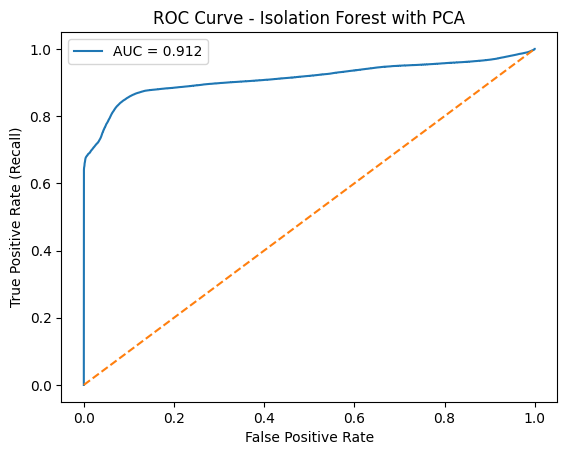

In [56]:
fpr, tpr, thresholds = roc_curve(y_test, -scores)

roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Isolation Forest with PCA")
plt.legend()

plt.show()

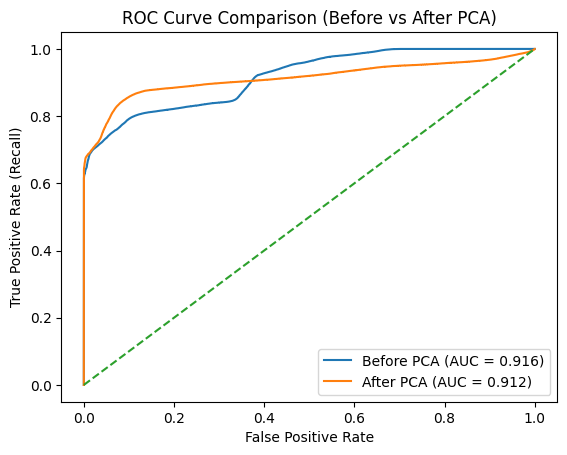

In [57]:
# ===== BEFORE PCA =====
scores_before = iso_before.decision_function(X_test_scaled)

fpr_before, tpr_before, _ = roc_curve(y_test, -scores_before)
auc_before = auc(fpr_before, tpr_before)

# ===== AFTER PCA =====
scores_after = iso_after.decision_function(X_test_pca)

fpr_after, tpr_after, _ = roc_curve(y_test, -scores_after)
auc_after = auc(fpr_after, tpr_after)

# ===== PLOT =====
plt.figure()

plt.plot(fpr_before, tpr_before, label=f"Before PCA (AUC = {auc_before:.3f})")
plt.plot(fpr_after, tpr_after, label=f"After PCA (AUC = {auc_after:.3f})")

# Random line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve Comparison (Before vs After PCA)")
plt.legend()

plt.show()

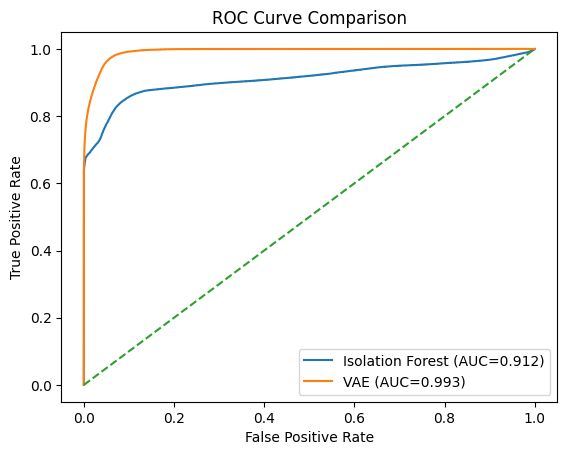

In [78]:
# Isolation Forest
fpr_iso, tpr_iso, _ = roc_curve(y_test, -scores)
auc_iso = auc(fpr_iso, tpr_iso)

# VAE
fpr_vae, tpr_vae, _ = roc_curve(y_test, recon_errors)
auc_vae = auc(fpr_vae, tpr_vae)


plt.figure()

plt.plot(fpr_iso, tpr_iso, label=f"Isolation Forest (AUC={auc_iso:.3f})")
plt.plot(fpr_vae, tpr_vae, label=f"VAE (AUC={auc_vae:.3f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()